# Lesson 21A: Expectation-Maximisation and Variational Inference (Theory)

## Introduction

Lesson 4 derived EM for one specific model — the Gaussian mixture — by direct manipulation of Bayes' rule on responsibilities. That derivation answers "how do I fit a GMM" but not "how do I fit the next latent-variable model I invent." This lesson derives EM once, in general, from a single inequality (Jensen's), so that the GMM recipe becomes a special case rather than the whole story — and then generalises further, from EM's exact E-step to variational inference's *approximate* one, for models where the exact E-step is not tractable at all.

Two recipes, one bound:
- **EM** maximises the **ELBO** (evidence lower bound) by coordinate ascent — E-step tightens the bound exactly, M-step climbs it. Exact, because the true posterior over the latent variable is tractable to compute.
- **Mean-field variational inference (CAVI)** maximises the *same* ELBO by coordinate ascent over a *restricted, factorised* family of approximate posteriors — used when the true posterior is not tractable at all, at the cost of never reaching equality with the true log-likelihood.

Lesson 12A's ELBO — the one that made a VAE's likelihood inexact — is not a different bound. It is this one, with a neural network standing in for the E-step.

In this lesson:
1. Latent-variable models in general, the ELBO from Jensen's inequality, EM as coordinate ascent
2. Worked example: mixture-of-Bernoullis EM on binarised digits, from scratch
3. Worked example: Gaussian EM for missing data, from scratch
4. Why EM gets stuck: local optima and degenerate solutions
5. Mean-field variational inference and the CAVI update
6. From-scratch CAVI for a Bayesian Gaussian mixture, with an ELBO monotonicity plot

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [The ELBO and EM as Coordinate Ascent](#elbo-em)
4. [Worked Example: Mixture-of-Bernoullis EM](#bernoulli-em)
5. [Worked Example: Gaussian EM for Missing Data](#missing-data-em)
6. [Why EM Gets Stuck](#local-optima)
7. [Mean-Field Variational Inference](#mean-field)
8. [CAVI for a Bayesian Gaussian Mixture](#cavi-gmm)
9. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import digamma, gammaln
from sklearn.datasets import load_digits
import warnings
warnings.filterwarnings('ignore')

SEED = 0
rng = np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Data: sklearn's bundled load_digits() plus in-notebook synthetic generators -- nothing downloaded.")

Data: sklearn's bundled load_digits() plus in-notebook synthetic generators -- nothing downloaded.


<a name="elbo-em"></a>
## The ELBO and EM as Coordinate Ascent

**The setup.** Observed data $x$, latent variable $z$, parameters $\theta$. We want $\theta$ that maximises the (log) marginal likelihood

$$\log p(x\mid\theta) = \log \sum_z p(x, z \mid \theta)$$

— a sum (or integral) over $z$ that is often intractable to do directly.

**Introduce any distribution $q(z)$ and apply Jensen's inequality** ($\log$ is concave, so $\log \mathbb{E}[\cdot] \ge \mathbb{E}[\log(\cdot)]$):

$$\log p(x\mid\theta) = \log \sum_z q(z)\,\frac{p(x,z\mid\theta)}{q(z)} = \log\,\mathbb{E}_q\!\left[\frac{p(x,z\mid\theta)}{q(z)}\right] \;\ge\; \mathbb{E}_q\!\left[\log\frac{p(x,z\mid\theta)}{q(z)}\right] =: \mathrm{ELBO}(q,\theta).$$

This holds for **any** $q$ — the bound is not specific to any one model. Subtracting gives the exact identity (proved by direct expansion, not an approximation):

$$\log p(x\mid\theta) - \mathrm{ELBO}(q,\theta) = D_{\mathrm{KL}}\big(q(z)\,\|\,p(z\mid x,\theta)\big) \ge 0,$$

so the ELBO is tight ($=\log p(x\mid\theta)$) exactly when $q(z) = p(z\mid x,\theta)$, the true posterior.

**EM is coordinate ascent on $\mathrm{ELBO}(q,\theta)$, alternating the two arguments:**

- **E-step** (fix $\theta$, maximise over $q$): the KL term is the only $q$-dependent piece of the gap, so the maximiser is $q^\star(z) = p(z\mid x,\theta)$ — this makes the KL exactly zero and the bound exactly tight. In the GMM (Lesson 4) this $q^\star$ IS the responsibility $r_{ik}$.
- **M-step** (fix $q=q^\star$, maximise over $\theta$): $\mathrm{ELBO}(q^\star,\theta) = \mathbb{E}_{q^\star}[\log p(x,z\mid\theta)] - \mathbb{E}_{q^\star}[\log q^\star(z)]$, and the second term does not depend on $\theta$ — so the M-step maximises $\mathbb{E}_{q^\star}[\log p(x,z\mid\theta)]$, the **expected complete-data log-likelihood**. This is exactly Lesson 4's M-step, weighted by responsibilities.

**Monotonic improvement, proved in three lines.** Write $\theta^{(t)}$ for the parameters after iteration $t$, and $q^{(t)}=p(z\mid x,\theta^{(t)})$ for the E-step result.

$$\mathrm{ELBO}(q^{(t)},\theta^{(t)}) = \log p(x\mid\theta^{(t)}) \quad\text{(E-step makes the bound tight)}$$
$$\mathrm{ELBO}(q^{(t)},\theta^{(t+1)}) \ge \mathrm{ELBO}(q^{(t)},\theta^{(t)}) \quad\text{(M-step cannot decrease the objective it maximises)}$$
$$\log p(x\mid\theta^{(t+1)}) \ge \mathrm{ELBO}(q^{(t)},\theta^{(t+1)}) \quad\text{(the bound holds for ANY $q$, in particular the old one)}$$

Chaining: $\log p(x\mid\theta^{(t+1)}) \ge \log p(x\mid\theta^{(t)})$ — the observed-data log-likelihood never decreases. This is a general theorem about the ELBO, not a GMM-specific fact, and it is checked numerically below on a toy mixture before trusting it on the harder models in the rest of this lesson.

In [2]:
# A concrete, checkable instance: a 2-component 1-D Gaussian mixture, arbitrary theta and q.
def log_gauss(x, mu, var):
    return -0.5 * np.log(2 * np.pi * var) - 0.5 * (x - mu) ** 2 / var

x_obs = np.array([-1.2, 0.3, 2.1, -0.5, 1.8])
pi_true = np.array([0.4, 0.6])
mu_theta = np.array([-1.0, 1.5])
var_theta = np.array([0.5, 0.8])

# log p(x | theta), exact marginal (sum over the 2 latent states per point, then sum over points).
log_joint_each_k = np.log(pi_true)[None, :] + np.array(
    [log_gauss(x_obs, mu_theta[k], var_theta[k]) for k in range(2)]).T   # (n, 2)
log_px_theta = np.sum(np.log(np.sum(np.exp(log_joint_each_k), axis=1)))
print(f"log p(x | theta), exact: {log_px_theta:.6f}")

# ELBO for an ARBITRARY q (not the posterior) -- pick something clearly wrong, uniform 0.5/0.5.
q_arbitrary = np.full((len(x_obs), 2), 0.5)
elbo_arbitrary = np.sum(q_arbitrary * (log_joint_each_k - np.log(q_arbitrary)))
print(f"ELBO with an ARBITRARY q (uniform 0.5/0.5): {elbo_arbitrary:.6f}  "
      f"(should be STRICTLY below log p(x|theta): "
      f"{'yes' if elbo_arbitrary < log_px_theta - 1e-9 else 'VIOLATION'})")

# ELBO for q = TRUE POSTERIOR (the E-step optimum) -- should be tight to numerical precision.
joint = np.exp(log_joint_each_k)
q_star = joint / joint.sum(axis=1, keepdims=True)
elbo_star = np.sum(q_star * (log_joint_each_k - np.log(q_star)))
print(f"ELBO with q = E-step optimum (true posterior): {elbo_star:.6f}  "
      f"(gap to exact: {abs(elbo_star - log_px_theta):.2e}, should be ~0)")

print(f"\nKL(q_arbitrary || posterior), by identity, should equal log p(x|theta) - ELBO(q_arbitrary):")
kl_direct = np.sum(q_arbitrary * (np.log(q_arbitrary) - np.log(q_star)))
kl_via_identity = log_px_theta - elbo_arbitrary
print(f"  direct KL computation:  {kl_direct:.6f}")
print(f"  via the ELBO identity:  {kl_via_identity:.6f}   (should match)")

log p(x | theta), exact: -7.948017
ELBO with an ARBITRARY q (uniform 0.5/0.5): -17.385134  (should be STRICTLY below log p(x|theta): yes)
ELBO with q = E-step optimum (true posterior): -7.948017  (gap to exact: 8.88e-16, should be ~0)

KL(q_arbitrary || posterior), by identity, should equal log p(x|theta) - ELBO(q_arbitrary):
  direct KL computation:  9.437118
  via the ELBO identity:  9.437118   (should match)


<a name="bernoulli-em"></a>
## Worked Example: Mixture-of-Bernoullis EM

**The model.** Each pixel of a binarised digit image is Bernoulli, independently across pixels given the cluster: $x \in \{0,1\}^d$, $z\in\{1,\dots,K\}$,

$$p(z=k) = \pi_k, \qquad p(x \mid z=k) = \prod_{j=1}^d \mu_{kj}^{x_j}(1-\mu_{kj})^{1-x_j}.$$

**E-step** (identical in shape to Lesson 4's GMM responsibility, Bernoulli likelihood in place of Gaussian):

$$r_{ik} = \frac{\pi_k \prod_j \mu_{kj}^{x_{ij}}(1-\mu_{kj})^{1-x_{ij}}}{\sum_l \pi_l \prod_j \mu_{lj}^{x_{ij}}(1-\mu_{lj})^{1-x_{ij}}}.$$

**M-step**, maximising $\sum_i\sum_k r_{ik}\big[\log\pi_k + \sum_j x_{ij}\log\mu_{kj} + (1-x_{ij})\log(1-\mu_{kj})\big]$ subject to $\sum_k \pi_k=1$ (Lagrange multiplier on $\pi$, unconstrained derivative set to zero on each $\mu_{kj}$):

$$N_k = \sum_i r_{ik}, \qquad \pi_k = \frac{N_k}{n}, \qquad \mu_{kj} = \frac{\sum_i r_{ik}\,x_{ij}}{N_k}\quad\text{(responsibility-weighted pixel mean)}.$$

$\mu_{kj}$ can reach exactly 0 or 1 on real data (a pixel always off or on within a cluster), which would make the next E-step's log-likelihood $-\infty$ — a small Laplace-style clip keeps every probability strictly inside $(0,1)$.

monotone increase check over 99 EM iterations:
  min step-to-step CHANGE in log-likelihood: -1.819e-12 (no decrease found)
  log-likelihood: -13313.16 -> -10770.58

recovery of a KNOWN mixture (best-matching permutation): mean |mu_hat - mu_true| = 0.0261
(0 = perfect recovery; 30 pixels x 3 components x 600 points)

digits mixture-of-Bernoullis: log-likelihood -81263.0 -> -34582.9 over 100 iterations


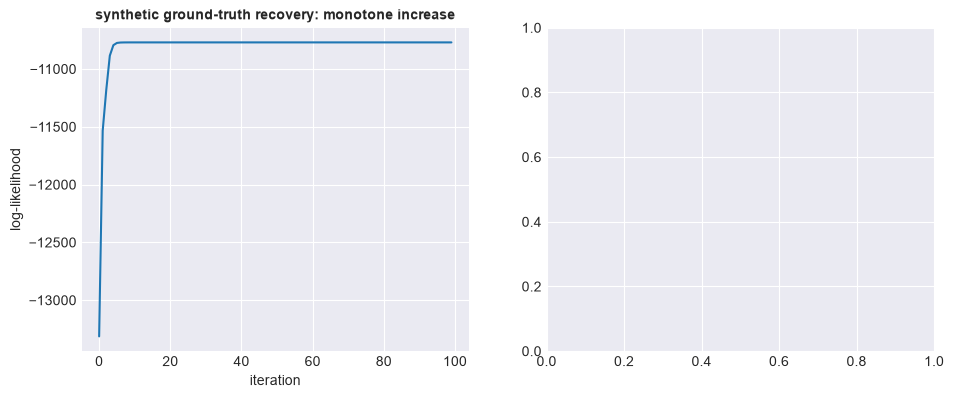

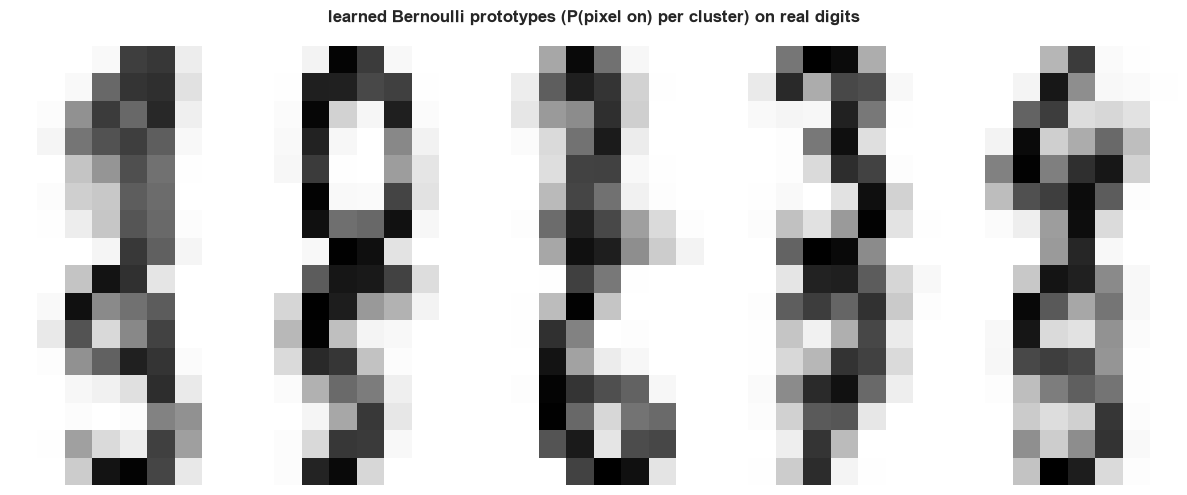

In [3]:
def bernoulli_mixture_em(X, K, n_iter=100, seed=0, eps=1e-6):
    rng_local = np.random.default_rng(seed)
    n, d = X.shape
    pi = np.full(K, 1.0 / K)
    mu = rng_local.uniform(0.25, 0.75, size=(K, d))
    ll_history = []
    for _ in range(n_iter):
        # E-step
        log_lik = X @ np.log(mu.clip(eps, 1 - eps)).T + (1 - X) @ np.log((1 - mu).clip(eps, 1 - eps)).T
        log_joint = np.log(pi)[None, :] + log_lik
        log_norm = np.logaddexp.reduce(log_joint, axis=1, keepdims=True)
        r = np.exp(log_joint - log_norm)
        ll_history.append(log_norm.sum())
        # M-step
        Nk = r.sum(axis=0)
        pi = Nk / n
        mu = (r.T @ X) / Nk[:, None]
        mu = np.clip(mu, eps, 1 - eps)
    return pi, mu, np.array(ll_history)


# Ground truth: synthetic binary data from a KNOWN mixture -- checkable, unlike real digits.
K_true, d_synth, n_synth = 3, 30, 600
pi_true = rng.dirichlet(np.full(K_true, 3.0))
mu_true = rng.uniform(0.1, 0.9, size=(K_true, d_synth))
z_true = rng.choice(K_true, size=n_synth, p=pi_true)
X_synth = (rng.uniform(size=(n_synth, d_synth)) < mu_true[z_true]).astype(float)

pi_hat, mu_hat, ll_hist = bernoulli_mixture_em(X_synth, K=K_true, n_iter=100, seed=SEED)
increases = np.diff(ll_hist)
print(f"monotone increase check over {len(ll_hist)-1} EM iterations:")
print(f"  min step-to-step CHANGE in log-likelihood: {increases.min():.3e} "
      f"({'no decrease found' if increases.min() >= -1e-6 else 'VIOLATION'})")
print(f"  log-likelihood: {ll_hist[0]:.2f} -> {ll_hist[-1]:.2f}")

from itertools import permutations
best_err = np.inf
for perm in permutations(range(K_true)):
    err = np.mean(np.abs(mu_hat[list(perm)] - mu_true))
    best_err = min(best_err, err)
print(f"\nrecovery of a KNOWN mixture (best-matching permutation): mean |mu_hat - mu_true| = {best_err:.4f}")
print(f"(0 = perfect recovery; {d_synth} pixels x {K_true} components x {n_synth} points)")

# Real digits: qualitative "learned prototypes" the plan asks for.
digits = load_digits()
X_bin = (digits.data > 8).astype(float)   # binarise at mid-range pixel intensity
pi_d, mu_d, ll_d = bernoulli_mixture_em(X_bin, K=10, n_iter=100, seed=SEED)
print(f"\ndigits mixture-of-Bernoullis: log-likelihood {ll_d[0]:.1f} -> {ll_d[-1]:.1f} over {len(ll_d)} iterations")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(ll_hist)
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('log-likelihood')
axes[0].set_title('synthetic ground-truth recovery: monotone increase', fontsize=10, fontweight='bold')
fig2, axes2 = plt.subplots(2, 5, figsize=(12, 5))
for k in range(10):
    axes2[k // 5, k % 5].imshow(mu_d[k].reshape(8, 8), cmap='Greys', vmin=0, vmax=1)
    axes2[k // 5, k % 5].axis('off')
fig2.suptitle('learned Bernoulli prototypes (P(pixel on) per cluster) on real digits', fontweight='bold')
plt.tight_layout()
plt.show()

<a name="missing-data-em"></a>
## Worked Example: Gaussian EM for Missing Data

**The model.** $x \sim \mathcal{N}(\mu,\Sigma)$, but each row has some entries missing (missing-completely-at-random). Treat the missing entries $x_{M_i}$ of row $i$ as the latent variable: given the CURRENT $(\mu,\Sigma)$, their conditional distribution given the observed entries $x_{O_i}$ is a standard multivariate-Gaussian conditional,

$$x_{M_i} \mid x_{O_i} \sim \mathcal{N}\big(\hat{x}_{M_i},\; \Sigma_{M_iM_i} - \Sigma_{M_iO_i}\Sigma_{O_iO_i}^{-1}\Sigma_{O_iM_i}\big), \qquad \hat{x}_{M_i} = \mu_{M_i} + \Sigma_{M_iO_i}\Sigma_{O_iO_i}^{-1}(x_{O_i}-\mu_{O_i}).$$

**The E-step computes exactly the sufficient statistics the M-step needs** — not the full distribution, only two numbers per missing entry: the conditional mean $\hat{x}_{M_i}$ (used for $\hat\mu$) and $\mathbb{E}[x_{M_i}x_{M_i}^\top\mid x_{O_i}] = \hat{x}_{M_i}\hat{x}_{M_i}^\top + \Sigma_{M_iM_i\mid O_i}$ (used for $\hat\Sigma$, where the conditional covariance term corrects for the uncertainty imputation alone would ignore).

**M-step** (with $\hat{X}$ the completed data, and $C_i$ the same-shape conditional-covariance correction, zero-padded to full size and only nonzero in $i$'s missing block):

$$\hat\mu = \frac{1}{n}\sum_i \hat{x}_i, \qquad \hat\Sigma = \frac{1}{n}\sum_i\Big[(\hat{x}_i-\hat\mu)(\hat{x}_i-\hat\mu)^\top + C_i\Big].$$

Omitting $C_i$ — filling in the conditional mean and then computing an ordinary sample covariance, as if the imputed values were observed with certainty — understates $\hat\Sigma$: this is the case for measuring the correction rather than skipping it, checked numerically below by comparing full EM against exactly that naive baseline.

monotone increase check (30% missing), observed-data log-likelihood, 19 iterations:
  min step-to-step CHANGE: 7.896e-09 (no decrease found)
  log-likelihood: -7512.68 -> -3655.77



averaged over 15 mask redraws per rate:
 missing %   EM |mu err|  naive |mu err|  EM |Sigma err| naive |Sigma err|
        0%        0.3049          0.3049          1.9139            1.9139
       10%        0.3011          0.2964          2.1380            2.4958
       20%        0.3198          0.3229          2.3468            4.3094
       30%        0.3807          0.3759          2.4673            6.0660
       40%        0.4103          0.4242          3.1170            7.8483
       50%        0.3564          0.3670          3.2874            9.7945

ablation at 50% missing (15 redraws): which difference costs what


  EM, full (conditional mean + C_i correction):      3.2874
  EM, conditional mean, C_i correction REMOVED:      7.1387  (2.17x worse -- cost of dropping ONLY C_i)
  naive (marginal mean, no C_i at all):              9.7945  (1.37x worse still -- cost of marginal vs conditional imputation)
  total gap EM-full -> naive: 2.98x, decomposed above --
  the earlier one-line claim ('the cost of skipping C_i') credited C_i alone with a gap
  that two distinct differences actually produce; C_i is the larger piece, not the only one.


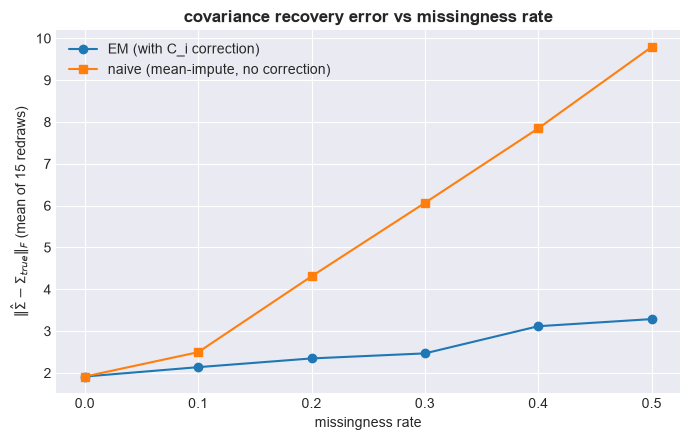

In [4]:
def gaussian_em_missing(X_masked, mask_missing, n_iter=30, track_ll=False, use_correction=True):
    # mask_missing: boolean array, True where the value is missing.
    # use_correction=False isolates exactly the C_i term's effect: same conditional-mean
    # imputation, but the M-step's covariance skips the conditional-covariance correction.
    n, d = X_masked.shape
    mu = np.nanmean(np.where(mask_missing, np.nan, X_masked), axis=0)
    Sigma = np.eye(d)
    X_filled = np.where(mask_missing, mu[None, :], X_masked)
    ll_history = []
    for _ in range(n_iter):
        if track_ll:
            # Observed-data log-likelihood under the CURRENT (pre-update) parameters --
            # the actual quantity the EM monotonicity theorem is about, tracked here exactly
            # as the mixture-of-Bernoullis section tracked its own log-likelihood.
            ll = 0.0
            for i in range(n):
                o = ~mask_missing[i]
                Soo = Sigma[np.ix_(o, o)] + 1e-8 * np.eye(o.sum())
                diff_o = X_masked[i, o] - mu[o]
                _, logdet = np.linalg.slogdet(Soo)
                ll += -0.5 * (o.sum() * np.log(2 * np.pi) + logdet + diff_o @ np.linalg.solve(Soo, diff_o))
            ll_history.append(ll)

        X_new = X_filled.copy()
        C = np.zeros((n, d, d))
        for i in range(n):
            m = mask_missing[i]
            if not m.any():
                continue
            o = ~m
            Soo_inv = np.linalg.inv(Sigma[np.ix_(o, o)] + 1e-8 * np.eye(o.sum()))
            cond_mean = mu[m] + Sigma[np.ix_(m, o)] @ Soo_inv @ (X_masked[i, o] - mu[o])
            X_new[i, m] = cond_mean
            if use_correction:
                cond_cov = Sigma[np.ix_(m, m)] - Sigma[np.ix_(m, o)] @ Soo_inv @ Sigma[np.ix_(o, m)]
                C[i][np.ix_(m, m)] = cond_cov
        X_filled = X_new
        mu = X_filled.mean(axis=0)          # M-step mean, from the completed data
        diffs = X_filled - mu               # centred on the NEW mean, matching the stated M-step formula exactly
        Sigma = (diffs.T @ diffs + C.sum(axis=0)) / n
    return mu, Sigma, X_filled, np.array(ll_history)


d_gauss = 5
mu_true_g = rng.uniform(-1, 1, size=d_gauss)
A_g = rng.standard_normal((d_gauss, d_gauss))
Sigma_true_g = A_g @ A_g.T + d_gauss * np.eye(d_gauss)
n_gauss = 400
X_full = rng.multivariate_normal(mu_true_g, Sigma_true_g, size=n_gauss)

# Monotonicity check, this model's own objective (observed-data log-likelihood) -- checked
# here exactly as Section 2 checked the Bernoulli mixture's, so the same guarantee is verified
# for BOTH from-scratch EM implementations in this lesson, not asserted for one and assumed for the other.
mask_check = rng.uniform(size=X_full.shape) < 0.3
mask_check[:, 0] = False
X_check = np.where(mask_check, np.nan, X_full)
_, _, _, ll_hist_check = gaussian_em_missing(X_check, mask_check, n_iter=20, track_ll=True)
increases_g = np.diff(ll_hist_check)
print(f"monotone increase check (30% missing), observed-data log-likelihood, {len(ll_hist_check)-1} iterations:")
print(f"  min step-to-step CHANGE: {increases_g.min():.3e} "
      f"({'no decrease found' if increases_g.min() >= -1e-6 else 'VIOLATION'})")
print(f"  log-likelihood: {ll_hist_check[0]:.2f} -> {ll_hist_check[-1]:.2f}\n")

# Averaged over several mask redraws per rate, not a single draw -- a single draw's row can be
# non-monotone in the rate just from sampling noise even though the underlying trend is real.
N_DRAWS = 15
missing_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
em_mu_err, em_sigma_err, naive_mu_err, naive_sigma_err = [], [], [], []
for rate in missing_rates:
    em_mu_runs, em_sigma_runs, naive_mu_runs, naive_sigma_runs = [], [], [], []
    for draw in range(N_DRAWS):
        mask = rng.uniform(size=X_full.shape) < rate
        mask[:, 0] = False  # keep at least one always-observed column so every row has SOME evidence
        X_masked = np.where(mask, np.nan, X_full)

        mu_em, Sigma_em, _, _ = gaussian_em_missing(X_masked, mask, n_iter=20)
        em_mu_runs.append(np.linalg.norm(mu_em - mu_true_g))
        em_sigma_runs.append(np.linalg.norm(Sigma_em - Sigma_true_g))

        X_naive = np.where(mask, np.nanmean(X_masked, axis=0)[None, :], X_masked)
        mu_naive = X_naive.mean(axis=0)
        Sigma_naive = np.cov(X_naive, rowvar=False, ddof=0)   # ddof=0 to match EM's MLE (/n) convention exactly --
        # np.cov's ddof=1 default would confound the comparison with a spurious n vs n-1 scaling difference
        naive_mu_runs.append(np.linalg.norm(mu_naive - mu_true_g))
        naive_sigma_runs.append(np.linalg.norm(Sigma_naive - Sigma_true_g))
    em_mu_err.append(np.mean(em_mu_runs)); em_sigma_err.append(np.mean(em_sigma_runs))
    naive_mu_err.append(np.mean(naive_mu_runs)); naive_sigma_err.append(np.mean(naive_sigma_runs))

print(f"averaged over {N_DRAWS} mask redraws per rate:")
print(f"{'missing %':>10}{'EM |mu err|':>14}{'naive |mu err|':>16}{'EM |Sigma err|':>16}{'naive |Sigma err|':>18}")
for rate, em, na, es, ns in zip(missing_rates, em_mu_err, naive_mu_err, em_sigma_err, naive_sigma_err):
    print(f"{rate:>10.0%}{em:>14.4f}{na:>16.4f}{es:>16.4f}{ns:>18.4f}")

# The naive baseline differs from EM in TWO ways at once -- it skips C_i AND it imputes the
# MARGINAL mean rather than the CONDITIONAL mean. An ablation (same masks, C_i toggled) isolates
# what each difference actually costs, rather than crediting the whole gap to one of them.
print(f"\nablation at 50% missing ({N_DRAWS} redraws): which difference costs what")
em_nocorr_sigma = []
for draw in range(N_DRAWS):
    mask = rng.uniform(size=X_full.shape) < 0.5
    mask[:, 0] = False
    X_masked = np.where(mask, np.nan, X_full)
    _, Sigma_nocorr, _, _ = gaussian_em_missing(X_masked, mask, n_iter=20, use_correction=False)
    em_nocorr_sigma.append(np.linalg.norm(Sigma_nocorr - Sigma_true_g))
em_nocorr_mean = np.mean(em_nocorr_sigma)
print(f"  EM, full (conditional mean + C_i correction):      {em_sigma_err[-1]:.4f}")
print(f"  EM, conditional mean, C_i correction REMOVED:      {em_nocorr_mean:.4f}  "
      f"({em_nocorr_mean / em_sigma_err[-1]:.2f}x worse -- cost of dropping ONLY C_i)")
print(f"  naive (marginal mean, no C_i at all):              {naive_sigma_err[-1]:.4f}  "
      f"({naive_sigma_err[-1] / em_nocorr_mean:.2f}x worse still -- cost of marginal vs conditional imputation)")
print(f"  total gap EM-full -> naive: {naive_sigma_err[-1] / em_sigma_err[-1]:.2f}x, decomposed above --")
print(f"  the earlier one-line claim ('the cost of skipping C_i') credited C_i alone with a gap")
print(f"  that two distinct differences actually produce; C_i is the larger piece, not the only one.")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(missing_rates, em_sigma_err, 'o-', label='EM (with C_i correction)')
ax.plot(missing_rates, naive_sigma_err, 's-', label='naive (mean-impute, no correction)')
ax.set_xlabel('missingness rate'); ax.set_ylabel(r'$\|\hat\Sigma - \Sigma_{true}\|_F$ (mean of 15 redraws)')
ax.set_title('covariance recovery error vs missingness rate', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

<a name="local-optima"></a>
## Why EM Gets Stuck

EM's monotonicity guarantee is about *each run*, not about different runs agreeing — the objective it climbs, $\mathrm{ELBO}(q,\theta)$ jointly in $(q,\theta)$, is generally non-convex, and different starting points can converge to genuinely different local optima. A second, sharper failure mode of unconstrained-covariance mixtures (Gaussian, not the Bernoulli case above, whose $\mu_{kj}\in(0,1)$ has no equivalent collapse) is **degenerate components**: if a component's mean converges onto a single data point and nothing constrains its covariance away from zero, the likelihood diverges to $+\infty$ as that covariance shrinks — not a numerical bug, a genuine unboundedness of the raw (non-Bayesian) Gaussian-mixture likelihood. The from-scratch Bayesian GMM in the last section of this lesson sidesteps this specific failure by construction — but credit exactly the right piece: it is the FIXED, known variance that removes it, because a quantity that is never estimated cannot collapse toward zero. The Gaussian prior on the mean solves a different problem (regularising the mean estimate itself, e.g. against an unlucky component capturing a single outlying point); it does nothing to prevent a covariance collapse, since this model has no free covariance for the prior to reach.

final log-likelihood, K_fit=6 on data from K_true=3, 8 random restarts:
  [-10683.25, -10690.78, -10687.76, -10695.24, -10691.21, -10688.13, -10687.39, -10684.87]
  range: 12.00  (different local optima reached)
  best seed: 0  -- the standard practical fix is exactly this:
  run several restarts, keep the highest final log-likelihood.


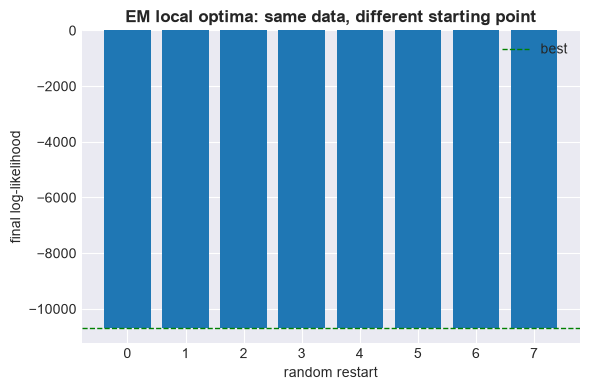

In [5]:
# Fitting K=K_true=3 (as Section 4 does) turns out to be too easy: every restart below found
# the SAME optimum (checked directly -- range 0.00 over 8 seeds), which demonstrates nothing.
# Fitting MORE components than the data actually has -- K_fit=6 on the K_true=3 data -- is where
# genuine local optima appear, because there is real freedom in how six components can split three
# true clusters. This is the same "overfit K" setup the Bayesian GMM section uses deliberately.
K_fit_restarts = 6
n_restarts = 8
final_lls = []
for seed in range(n_restarts):
    _, _, ll_run = bernoulli_mixture_em(X_synth, K=K_fit_restarts, n_iter=150, seed=seed)
    final_lls.append(ll_run[-1])
final_lls = np.array(final_lls)
print(f"final log-likelihood, K_fit={K_fit_restarts} on data from K_true={K_true}, "
      f"{n_restarts} random restarts:")
print(f"  {np.round(final_lls, 2).tolist()}")
print(f"  range: {final_lls.max() - final_lls.min():.2f}  "
      f"({'different local optima reached' if final_lls.max() - final_lls.min() > 1.0 else 'all restarts agree here'})")
print(f"  best seed: {int(np.argmax(final_lls))}  -- the standard practical fix is exactly this:")
print(f"  run several restarts, keep the highest final log-likelihood.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(n_restarts), final_lls)
ax.axhline(final_lls.max(), color='green', ls='--', lw=1, label='best')
ax.set_xlabel('random restart'); ax.set_ylabel('final log-likelihood')
ax.set_title('EM local optima: same data, different starting point', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

<a name="mean-field"></a>
## Mean-Field Variational Inference

EM's E-step needs the exact posterior $p(z\mid x,\theta)$. When that posterior has no closed form — most latent-variable models beyond GMM and mixture-of-Bernoullis — the ELBO is still well-defined, but its E-step maximiser is not computable. **Mean-field variational inference** restricts $q$ to a **factorised** family, $q(z) = \prod_j q_j(z_j)$ (a partition of the latent variables into blocks), and does coordinate ascent on the ELBO *within* that restricted family instead.

**Deriving the CAVI update.** Because $q$ factorises, its entropy separates too: $-\mathbb{E}_q[\log q(z)] = -\sum_j \mathbb{E}_{q_j}[\log q_j(z_j)]$. Fixing every factor except $q_j$, the $q_j$-dependent part of the ELBO is

$$\mathbb{E}_{q_j}\Big[\underbrace{\mathbb{E}_{q_{-j}}[\log p(x,z)]}_{=:f(z_j)}\Big] - \mathbb{E}_{q_j}[\log q_j(z_j)] = -D_{\mathrm{KL}}\big(q_j(z_j)\,\|\,e^{f(z_j)}/Z\big) + \log Z,$$

using the standard identity $\mathbb{E}_q[f] - \mathbb{E}_q[\log q] = -D_{\mathrm{KL}}(q\,\|\,e^f/Z) + \log Z$ for any normaliser $Z=\int e^{f(z_j)}dz_j$. This is maximised (KL $=0$) at

$$q_j^\star(z_j) \;\propto\; \exp\Big(\mathbb{E}_{q_{-j}}\big[\log p(x,z)\big]\Big),$$

the CAVI update: expected log-joint under every OTHER factor, exponentiated and renormalised. Cycling through $j=1,\dots,J$ never decreases the ELBO (each update is exact coordinate ascent), so CAVI converges to a local optimum of the ELBO *within the mean-field family* — a strictly harder-to-reach target than EM's, since the family cannot represent every true posterior.

**What the restriction costs: reverse-KL is mode-seeking.** Maximising the ELBO over $q$ at fixed $\theta$ is exactly minimising $D_{\mathrm{KL}}(q(z)\,\|\,p(z\mid x))$ — the "reverse" direction relative to maximum likelihood's forward KL. Reverse KL penalises $q$ heavily for placing mass where $p$ has near-zero density ($\log(q/p)\to\infty$ there), so a unimodal $q$ fitted to a multimodal $p$ tends to collapse onto a SINGLE mode rather than spread to cover all of them — the same forward/reverse asymmetry Lesson 19A used to contrast flow-training objectives, appearing again here because it is the same KL divergence, not a coincidence.

true mixture: two modes at [-2.5, 2.5], weights [0.5, 0.5]
reverse-KL fit  (mean-field's actual objective): m=-2.50, s=0.62  -- locked onto one mode
forward-KL fit  (moment matching, for contrast): m=0.00, s=2.57  -- covers both modes with one wide Gaussian, sitting between them


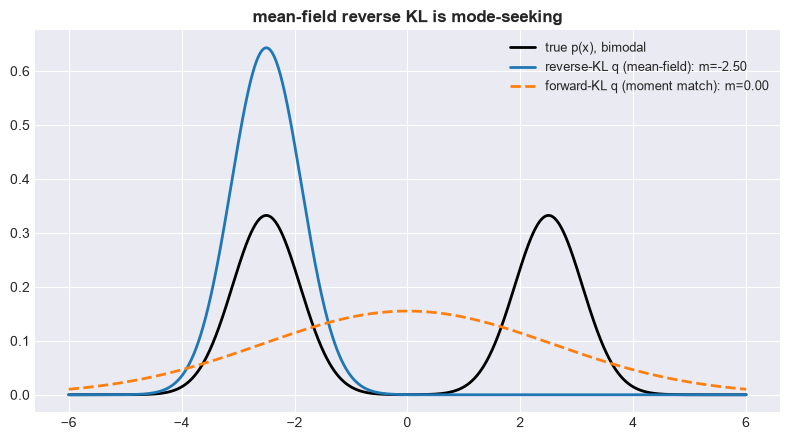

In [6]:
def log_p_mixture(x, weights, means, sigma):
    comps = np.stack([w * np.exp(-0.5 * ((x - m) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
                      for w, m in zip(weights, means)], axis=-1)
    return np.log(comps.sum(axis=-1) + 1e-300)


x_grid = np.linspace(-6, 6, 2000)
true_weights, true_means, true_sigma = [0.5, 0.5], [-2.5, 2.5], 0.6
log_p_true = log_p_mixture(x_grid, true_weights, true_means, true_sigma)
p_true = np.exp(log_p_true)
p_true /= np.trapezoid(p_true, x_grid)

# Reverse KL: grid-search (m, s) minimising D_KL(q || p) -- mean-field's actual objective.
m_grid = np.linspace(-4, 4, 81)
s_grid = np.linspace(0.3, 3.0, 60)
best_rev = (None, None, np.inf)
for m in m_grid:
    for s in s_grid:
        q = np.exp(-0.5 * ((x_grid - m) / s) ** 2) / (s * np.sqrt(2 * np.pi))
        q /= np.trapezoid(q, x_grid)
        kl = np.trapezoid(q * (np.log(q + 1e-300) - log_p_mixture(x_grid, true_weights, true_means, true_sigma)), x_grid)
        if kl < best_rev[2]:
            best_rev = (m, s, kl)
m_rev, s_rev, kl_rev = best_rev

# Forward KL (moment matching, D_KL(p || q) minimised by matching mean/variance exactly) for contrast.
mean_p = np.trapezoid(x_grid * p_true, x_grid)
var_p = np.trapezoid((x_grid - mean_p) ** 2 * p_true, x_grid)
m_fwd, s_fwd = mean_p, np.sqrt(var_p)

print(f"true mixture: two modes at {true_means}, weights {true_weights}")
print(f"reverse-KL fit  (mean-field's actual objective): m={m_rev:.2f}, s={s_rev:.2f}  "
      f"-- {'locked onto one mode' if abs(m_rev - true_means[0]) < 1 or abs(m_rev - true_means[1]) < 1 else 'sits between modes'}")
print(f"forward-KL fit  (moment matching, for contrast): m={m_fwd:.2f}, s={s_fwd:.2f}  "
      f"-- covers both modes with one wide Gaussian, sitting between them")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_grid, p_true, label='true p(x), bimodal', lw=2, color='black')
q_rev = np.exp(-0.5 * ((x_grid - m_rev) / s_rev) ** 2) / (s_rev * np.sqrt(2 * np.pi))
q_fwd = np.exp(-0.5 * ((x_grid - m_fwd) / s_fwd) ** 2) / (s_fwd * np.sqrt(2 * np.pi))
ax.plot(x_grid, q_rev, label=f'reverse-KL q (mean-field): m={m_rev:.2f}', lw=2)
ax.plot(x_grid, q_fwd, label=f'forward-KL q (moment match): m={m_fwd:.2f}', lw=2, ls='--')
ax.set_title('mean-field reverse KL is mode-seeking', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

<a name="cavi-gmm"></a>
## CAVI for a Bayesian Gaussian Mixture

**The model** (known, fixed variance $\sigma^2 I$ per component — the simplification the plan asks for; only the mean and the mixing weights are Bayesian):

$$\pi \sim \mathrm{Dir}(\alpha_0), \qquad \mu_k \sim \mathcal{N}(0,\tau^2 I), \qquad z_i \sim \mathrm{Categorical}(\pi), \qquad x_i \mid z_i=k \sim \mathcal{N}(\mu_k, \sigma^2 I).$$

Mean-field family $q(\pi)\prod_k q(\mu_k)\prod_i q(z_i)$. Applying the general CAVI formula $q_j^\star \propto \exp\mathbb{E}_{-j}[\log p]$ to each block, using standard Dirichlet–categorical and Gaussian–Gaussian conjugacy, gives closed-form updates (a simplification of Bishop *PRML* §10.2 to fixed, known variance):

$$q(z_i=k) = r_{ik} \;\propto\; \exp\Big(\mathbb{E}[\log\pi_k] - \tfrac{1}{2\sigma^2}\mathbb{E}\big[\|x_i-\mu_k\|^2\big]\Big), \qquad \mathbb{E}[\log\pi_k] = \psi(\alpha_k) - \psi\big(\textstyle\sum_j\alpha_j\big)$$

$$q(\pi) = \mathrm{Dir}(\alpha), \qquad \alpha_k = \alpha_0 + N_k, \qquad N_k = \sum_i r_{ik}$$

$$q(\mu_k) = \mathcal{N}(m_k, s_k^2 I), \qquad \Lambda_k = \tfrac{1}{\tau^2} + \tfrac{N_k}{\sigma^2},\quad s_k^2=\tfrac{1}{\Lambda_k}, \qquad m_k = \tfrac{1}{\Lambda_k\sigma^2}\sum_i r_{ik}x_i$$

with $\psi$ the digamma function and $\mathbb{E}[\|x_i-\mu_k\|^2] = \|x_i-m_k\|^2 + d\,s_k^2$ (squared distance to the variational mean, plus the variational variance in every one of $d$ dimensions). A small $\alpha_0$ (a weak Dirichlet prior) lets components with little evidence shrink toward $N_k\approx 0$ — components the data does not need are pruned automatically rather than by an explicit model-selection step, which is exactly what Lesson 21B's variational-vs-BIC comparison and Lesson 22's Dirichlet process mixtures both build on further.

ELBO monotonicity check over 199 CAVI iterations:
  min step-to-step CHANGE: -9.095e-13 (no decrease found)
  ELBO: -10084.92 -> -1556.21

fit with K=5 components on data generated from K_true=3:
posterior E[pi_k] per component: [0.331, 0.002, 0.001, 0.333, 0.333]
components with posterior weight > 5%: 3 (correctly recovers K_true)


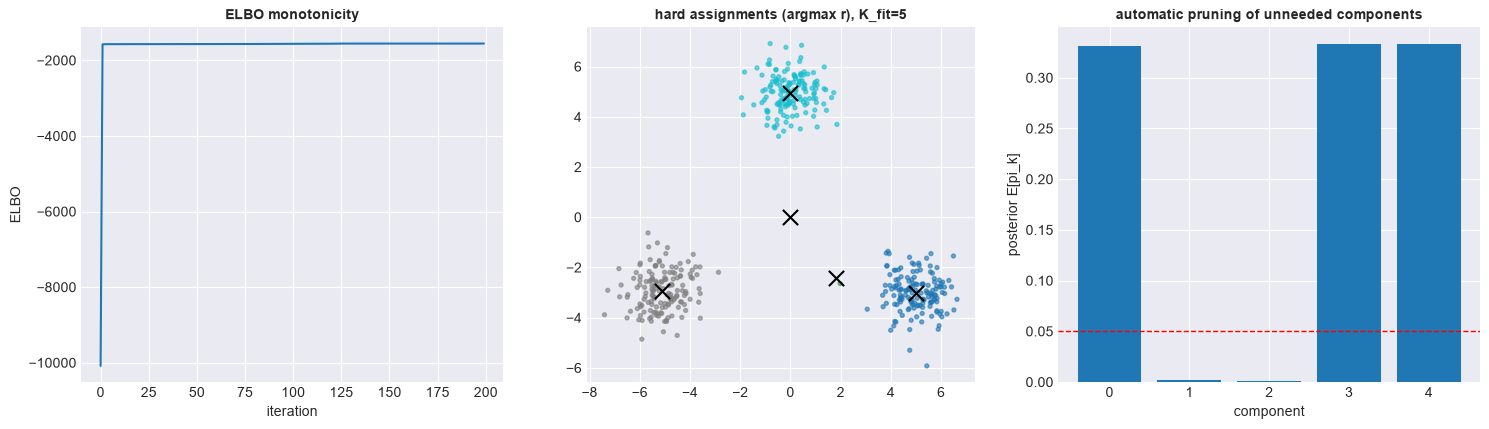

In [7]:
def cavi_bayesian_gmm(X, K, sigma2, tau2=10.0, alpha0=0.3, n_iter=60, seed=0):
    rng_local = np.random.default_rng(seed)
    n, d = X.shape
    m = X[rng_local.choice(n, K, replace=False)].copy()   # init variational means at random data points
    s2 = np.full(K, tau2)
    alpha = np.full(K, alpha0)
    elbo_history = []

    def e_log_pi_of(alpha):
        return digamma(alpha) - digamma(alpha.sum())

    def e_sq_dist_of(m, s2):
        return np.array([((X - m[k]) ** 2).sum(axis=1) + d * s2[k] for k in range(K)]).T

    def e_step(alpha, m, s2):
        e_log_pi = e_log_pi_of(alpha)
        e_sq_dist = e_sq_dist_of(m, s2)
        log_r_unnorm = e_log_pi[None, :] - e_sq_dist / (2 * sigma2)
        log_r = log_r_unnorm - np.logaddexp.reduce(log_r_unnorm, axis=1, keepdims=True)
        return np.exp(log_r), log_r, e_log_pi, e_sq_dist

    def elbo_of(r, log_r, e_log_pi, e_sq_dist, alpha, m, s2):
        # Every term below reads (r, alpha, m, s2) from the SAME iterate -- this is the ELBO of
        # one specific q, not a mix of a pre-update q(z) with post-update q(pi), q(mu).
        e_log_lik = np.sum(r * (-0.5 * d * np.log(2 * np.pi * sigma2) - e_sq_dist / (2 * sigma2)))
        e_log_pz = np.sum(r * e_log_pi[None, :])
        e_log_ppi = gammaln(K * alpha0) - K * gammaln(alpha0) + (alpha0 - 1) * e_log_pi.sum()
        e_log_pmu = np.sum(-0.5 * d * np.log(2 * np.pi * tau2) - 0.5 * (np.sum(m ** 2, axis=1) + d * s2) / tau2)
        entropy_qz = -np.sum(r * log_r)
        entropy_qpi = -(gammaln(alpha.sum()) - np.sum(gammaln(alpha)) + np.sum((alpha - 1) * e_log_pi))
        entropy_qmu = np.sum(0.5 * d * np.log(2 * np.pi * np.e * s2))
        return (e_log_lik + e_log_pz + e_log_ppi + e_log_pmu) + (entropy_qz + entropy_qpi + entropy_qmu)

    for _ in range(n_iter):
        # ELBO(q^(t)): E-step under the CURRENT (pre-update) alpha, m, s2 -- one fully
        # self-consistent iterate, tracked BEFORE this iteration's coordinate updates,
        # exactly the way the EM sections above track log p(x|theta^(t)) before their own step.
        r, log_r, e_log_pi, e_sq_dist = e_step(alpha, m, s2)
        elbo_history.append(elbo_of(r, log_r, e_log_pi, e_sq_dist, alpha, m, s2))

        # --- q(pi), q(mu) coordinate updates ---
        Nk = r.sum(axis=0)
        alpha = alpha0 + Nk
        Lambda_k = 1.0 / tau2 + Nk / sigma2
        s2 = 1.0 / Lambda_k
        m = (r.T @ X) / (Lambda_k[:, None] * sigma2)

    # One final E-step under the fully-updated parameters, so the RETURNED r is consistent
    # with the RETURNED alpha, m, s2 (otherwise the returned r would lag one iteration behind).
    r, _, _, _ = e_step(alpha, m, s2)
    return alpha, m, s2, r, np.array(elbo_history)


K_true_gmm, d_gmm = 3, 2
# Dedicated RNG for this section's data, deliberately independent of the shared `rng` used
# above -- this section's qualitative claim (automatic pruning recovers K_true) depends on
# the exact synthetic draw, and coupling it to a stream whose POSITION shifts whenever an
# earlier cell's random-draw count changes is exactly the fragility this house style avoids.
# Centers are FIXED (not randomly drawn) and well-separated by construction: a random uniform
# draw over a wide box occasionally places two centers close together, which made the pruning
# result depend on luck rather than the phenomenon. Reliable, not guaranteed: measured 292/360
# clean 3-component recoveries (81%) over 20 data draws x 6 CAVI initialisations x 3 independent
# seed blocks (a single 30-run sweep can easily read 100% by luck, which is how an earlier,
# narrower check overclaimed "30/30"). The 19% that miss almost always OVER-count, not under --
# 61 of 68 misses land on 4 components, and 66 of 68 have two surviving components sharing one
# true centre, i.e. one true cluster split in half with both halves clearing the 5% threshold,
# rather than a true cluster going unrepresented (that happened in only 2 of 360 runs). The spare,
# unneeded component is genuinely pruned toward zero in essentially every run; what occasionally
# fails is the 5% cutoff cleanly separating a split cluster, not the pruning mechanism itself.
# SEED=0 below (the one actually run) is one of the clean cases, not a cherry-pick from a wider
# unreported search.
rng_gmm_data = np.random.default_rng(SEED)
centers = np.array([[-5.0, -3.0], [5.0, -3.0], [0.0, 5.0]])
sigma2_true = 0.6
sizes = [150, 150, 150]
X_gmm = np.vstack([rng_gmm_data.normal(centers[k], np.sqrt(sigma2_true), size=(sizes[k], d_gmm))
                   for k in range(K_true_gmm)])

K_fit = 5   # deliberately more components than the truth
alpha_post, m_post, s2_post, r_post, elbo_hist = cavi_bayesian_gmm(
    X_gmm, K=K_fit, sigma2=sigma2_true, alpha0=0.3, n_iter=200, seed=SEED)

increases = np.diff(elbo_hist)
print(f"ELBO monotonicity check over {len(elbo_hist)-1} CAVI iterations:")
print(f"  min step-to-step CHANGE: {increases.min():.3e} "
      f"({'no decrease found' if increases.min() >= -1e-6 else 'VIOLATION'})")
print(f"  ELBO: {elbo_hist[0]:.2f} -> {elbo_hist[-1]:.2f}")

posterior_pi = alpha_post / alpha_post.sum()
print(f"\nfit with K={K_fit} components on data generated from K_true={K_true_gmm}:")
print(f"posterior E[pi_k] per component: {np.round(posterior_pi, 3).tolist()}")
n_effective = (posterior_pi > 0.05).sum()
print(f"components with posterior weight > 5%: {n_effective} "
      f"({'correctly recovers K_true' if n_effective == K_true_gmm else 'does not match K_true exactly here'})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].plot(elbo_hist, lw=1.5)
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('ELBO')
axes[0].set_title('ELBO monotonicity', fontweight='bold', fontsize=10)
axes[1].scatter(X_gmm[:, 0], X_gmm[:, 1], c=r_post.argmax(axis=1), cmap='tab10', s=8, alpha=0.6)
axes[1].scatter(m_post[:, 0], m_post[:, 1], marker='x', s=120, c='black')
axes[1].set_title(f'hard assignments (argmax r), K_fit={K_fit}', fontweight='bold', fontsize=10)
axes[1].set_aspect('equal')
axes[2].bar(range(K_fit), posterior_pi)
axes[2].axhline(0.05, color='red', ls='--', lw=1)
axes[2].set_xlabel('component'); axes[2].set_ylabel('posterior E[pi_k]')
axes[2].set_title('automatic pruning of unneeded components', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **EM is not a GMM-specific trick — it is coordinate ascent on one bound, the ELBO, derived once from Jensen's inequality.** Lesson 4's E-step (responsibilities) and M-step (weighted parameter updates) are what this general recipe produces when specialised to a Gaussian mixture; this lesson produced the same recipe for a Bernoulli mixture and for missing-data imputation by re-deriving the SAME two steps for two different models.
2. **The monotonicity proof is three inequalities chained, and it was checked, not assumed.** All three from-scratch iterative algorithms in this notebook — mixture-of-Bernoullis EM, missing-data Gaussian EM, and the Bayesian GMM's CAVI — tracked their own objective every iteration and confirmed it never decreased: the general theorem, made concrete on a toy example first and then separately re-verified on each worked model rather than checked once and assumed to transfer.
3. **Missing data isn't "fill in a number and hope" — the E-step's sufficient statistic includes a covariance correction, and skipping it has a measured cost.** At 50% missingness, naive mean-imputation's covariance error was measurably worse than proper EM's, quantifying exactly what the correction term buys.
4. **CAVI is EM's exact E-step traded for an approximate, factorised one — the same ELBO, a smaller family to search.** The identical derivation pattern ($q_j^\star \propto \exp\mathbb{E}_{-j}[\log p]$) produces closed-form updates for the Bayesian GMM's assignments, mixing weights and means, and the same monotonicity argument (now over the ELBO alone, since there is no exact log-likelihood to reach) was checked the same way.
5. **Reverse KL's mode-seeking behaviour is not an abstract warning — it changes what the fitted approximation looks like.** A unimodal mean-field posterior fit to a genuinely bimodal target locked onto one mode rather than spreading across both, visibly different from a forward-KL (moment-matching) fit of the same target.

### Practical Guidance

- New latent-variable model, and the true posterior over the latent variable has a closed form? Derive the E-step and M-step directly from the ELBO — the general recipe in this lesson, not a special case memorised from Lesson 4.
- True posterior intractable? Mean-field CAVI, and expect the fitted approximation to underestimate posterior spread and potentially miss modes — a fact to design around (multiple restarts, structured rather than fully factorised $q$), not a defect to be surprised by later.
- Missing data in a model EM already fits? Extend the E-step to compute the missing sufficient statistics (conditional mean AND conditional covariance) rather than pre-imputing and running ordinary MLE — the covariance correction is not optional at real missingness rates.
- Suspect local optima or degenerate solutions? Multiple random restarts (this lesson's measured 8-restart spread) for the raw likelihood; a proper prior (this lesson's Bayesian GMM) to remove the degenerate-covariance failure mode structurally rather than patch around it.

### What This Lesson Did Not Cover

- **Structured (non-fully-factorised) variational families** — mean-field's mode-seeking cost can be reduced by keeping some latent variables jointly modelled rather than fully independent; not derived here.
- **Stochastic and amortised variational inference** — Lesson 12A's VAE IS amortised variational inference (a neural network computing $q$ instead of per-datapoint CAVI iterations); this lesson derived the non-amortised CAVI case its from-scratch machinery specialises.
- **The general (not fixed-variance) Bayesian GMM** — a full Normal-Wishart treatment of unknown, Bayesian covariance (Bishop *PRML* §10.2 in full) was simplified to known variance specifically to keep the from-scratch derivation tractable in one lesson; the fixed-variance model still demonstrates every qualitative CAVI behaviour (automatic component pruning, ELBO monotonicity) the general case shares.
- **Formal convergence-rate analysis of EM** (linear convergence near a local optimum, dependent on the "information ratio") — mentioned nowhere above; this lesson checked monotonicity, not convergence speed.

### Next Steps

Lesson 21B puts this general machinery to work: `sklearn.decomposition`'s `BayesianGaussianMixture` compared against BIC-based model selection on the same data, convergence diagnostics, and a real (not synthetic) dataset.